# Interactive Introduction to Image Processing
Welcome! This notebook is designed for beginners with no prior experience in image processing. You'll learn how images are represented in code and get hands-on with common image transforms, filters, and detection techniques using Python.

## Why this matters
Image processing is everywhere: improving medical images, cleaning up photos, extracting measurements, and powering computer vision systems such as object detectors and trackers. This notebook focuses on the practical building blocks you can reuse across projects.

## What you'll learn
- How images are represented (pixels, channels, color spaces)
- Basic transforms: resizing, rotating, and cropping
- Filters: blur, sharpen, edge detection, and morphological ops
- How to inspect image statistics using histograms
- How to detect objects and faces using modern libraries
- Practical tips for tuning parameters and debugging outputs

## Requirements

To run this notebook, you need the following:

- **Python 3.8+**
- **Jupyter Notebook** (or JupyterLab)

## Tips before you start
- Run cells sequentially so variables (like `img`) are available.
- If an example is slow, reduce sizes (resize to 320x240) for faster iteration.
- Use the provided `test_image.jpg` or change the filename to your own image.

## Resources & next steps
- OpenCV documentation: https://docs.opencv.org/
- Ultralytics (YOLO) docs: https://docs.ultralytics.com/
- MediaPipe face detection: https://developers.google.com/mediapipe

In [ ]:
# Install required packages
%pip install opencv-python matplotlib numpy ultralytics mediapipe ipython

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image

# Direct download links for Box files
IMG_URL = 'https://uofi.box.com/shared/static/4vwmy8d4zutugdq54xj0jm98y2dsv8t0.jpg'
VIDEO_URL = 'https://uofi.box.com/shared/static/of08em0yjvobx6xoqtxzk02glq9d8e55.mp4'
YOLO_URL = 'https://uofi.box.com/shared/static/pma36x7cge58b3i18b2o0xqlcqd38iwk.pt'

def download_file(url, save_path):
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(save_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    return save_path

# Download files to /content/
img_path = '/content/test_image.jpg'
video_path = '/content/GX010881.MP4'
yolo_path = '/content/yolo11n.pt'

download_file(IMG_URL, img_path)
download_file(VIDEO_URL, video_path)
download_file(YOLO_URL, yolo_path)

# Load image
img = cv2.imread(img_path)
print('Image loaded:', img is not None)

# Load video
video = cv2.VideoCapture(video_path)
print('Video loaded:', video.isOpened())

# Check YOLO model file
print('YOLO model downloaded:', os.path.exists(yolo_path))

## Object Detection and Face Detection

Modern image processing leverages deep learning models to automatically detect and localize objects and faces in images and videos. Two popular approaches are **YOLO (You Only Look Once)** for general object detection and **MediaPipe Face Detection** for fast, lightweight face localization.



### YOLO Object Detection
- **YOLO** is a family of real-time object detectors that predict bounding boxes and class labels for multiple objects in a single pass through the image.
- **How it works:** YOLO divides the image into a grid and simultaneously predicts bounding boxes and class probabilities for each cell.
- **Advantages:** Fast, accurate, and suitable for real-time applications such as video analysis, robotics, and surveillance.
- **Use cases:** Detecting people, vehicles, animals, and everyday objects in images or video frames.

In [ ]:
# Step 3: Object Detection with YOLO
from ultralytics import YOLO

# The YOLO model loaded above (yolo_model) is a pre-trained deep learning object detector from the Ultralytics YOLO family.
# YOLO ("You Only Look Once") models are designed for real-time object detection in images and videos.
# They predict bounding boxes and class labels for multiple objects in a single forward pass.
# The model file 'yolo11n.pt' is a specific version/size of YOLO.

yolo_model = YOLO('yolo11n.pt')

# Load the first frame of the video file and use it as the image
video_path = 'GX010881.MP4'  # Change to your video file name if needed
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
if ret:
    img = frame
    # Run YOLO detection on the first frame
    results = yolo_model(img)
    img_detected = img.copy()
    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = yolo_model.names[class_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            if confidence > 0.2:
                cv2.rectangle(img_detected, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img_detected, f'{class_name} {confidence:.2f}',
                            (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    img_detected_rgb = cv2.cvtColor(img_detected, cv2.COLOR_BGR2RGB)
    plt.imshow(img_detected_rgb)
    plt.title('YOLO Object Detection (First Video Frame)')
    plt.axis('off')
    plt.show()
else:
    print('Could not load first frame from video.')

### MediaPipe Face Detection
- **MediaPipe** is a framework from Google for building cross-platform ML pipelines. Its face detection model is designed for real-time applications and works well on both close-up and wide-angle scenes.
- **How it works:** The model uses machine learning to find faces and estimate their bounding boxes, returning confidence scores for each detection.
- **Advantages:** Lightweight, fast, and robust to variations in pose and lighting.
- **Use cases:** Face tracking, privacy blurring, selfie enhancement, and interactive applications.

In [ ]:
# Step 4: Face Detection with MediaPipe
import mediapipe as mp

# The MediaPipe Face Detection model is a lightweight, real-time face detector from Google.
# It uses machine learning to find faces and estimate their bounding boxes in images or video frames.
# The model is fast and works well for both close-up selfies and wider scenes, depending on the model_selection parameter.
# It outputs detection objects with bounding box coordinates and confidence scores.
mp_face_detection = mp.solutions.face_detection

if img is not None:
    # Tip: model_selection=0 is tuned for close-up faces (e.g., selfies); model_selection=1 is for wider scenes.
    # Tip: increase min_detection_confidence (0.0-1.0) to reduce false positives at the cost of missing faint faces.
    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as face_detection:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = face_detection.process(img_rgb)
        img_faces = img_rgb.copy()
        h_img, w_img = img_faces.shape[:2]
        if results.detections:
            for detection in results.detections:
                bboxC = detection.location_data.relative_bounding_box
                x = int(bboxC.xmin * w_img)
                y = int(bboxC.ymin * h_img)
                w = int(bboxC.width * w_img)
                h = int(bboxC.height * h_img)
                cv2.rectangle(img_faces, (x, y),
                              (x + w, y + h), (255, 0, 0), 2)
            plt.imshow(img_faces)
            plt.title('MediaPipe Face Detection')
            plt.axis('off')
            plt.show()
            # Note: each detection object has a score (detection.score). You can filter detections by inspecting that value.
            print(f'Faces detected: {len(results.detections)}')
        else:
            print('No faces detected.')
else:
    print('Image not loaded. Run the first cell.')

### Video Processing: Object and Face Detection with Privacy Blurring

The next cell defines and runs a function called `process_video` that processes a video file frame-by-frame. For each frame, it performs:

- **Object Detection (YOLO):**  
    Uses the YOLO model to detect people in the frame and draws green rectangles around them.

- **Face Detection (MediaPipe):**  
    Uses MediaPipe to detect faces, draws blue rectangles around each detected face, and applies a blur to the face region for privacy protection.

- **Interactive Display:**  
    The processed frames are displayed interactively in the notebook, allowing you to watch the detection and blurring in real time.

- **Robust Face Tracking:**  
    If a face is missed in a frame, the function keeps the last known face location for a few frames to maintain privacy blurring even during brief detection failures.

This workflow demonstrates how to combine deep learning-based object detection and lightweight face detection for privacy-aware video analysis in Python.

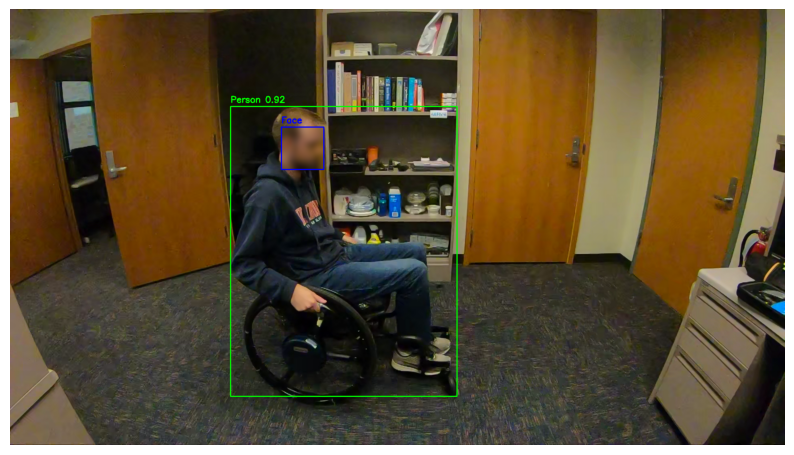

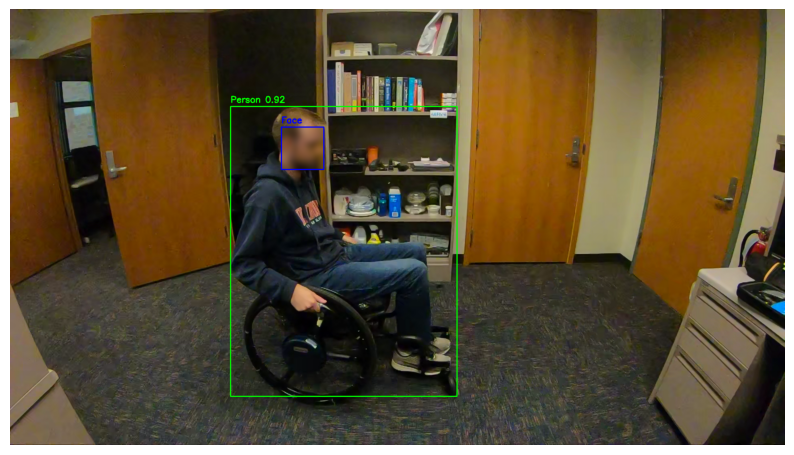

In [ ]:
from IPython.display import display, clear_output
import contextlib
import os
from ultralytics import YOLO


def _get_valid_ksize(fw, fh, base=51):
    ksize = min(fw, fh, base)
    ksize = max(ksize, 3)
    if ksize % 2 == 0:
        ksize += 1
    return int(ksize)


def process_video(video_path, max_frames=30, max_missed=5):
    yolo_model = YOLO('yolo11n.pt')
    mp_face_detection = mp.solutions.face_detection
    cap = cv2.VideoCapture(video_path)
    last_face_boxes = []
    missed_frames = 0
    frames_shown = 0
    fig, ax = plt.subplots(figsize=(10, 6))
    img_plot = None
    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as face_detection:
        while cap.isOpened() and frames_shown < max_frames:
            ret, frame = cap.read()
            if not ret:
                print('End of video or cannot read the frame.')
                break
            # YOLO person detection (suppress output)
            with open(os.devnull, 'w') as fnull, contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
                results = yolo_model(frame, verbose=False)
            for result in results:
                for box in result.boxes:
                    class_id = int(box.cls[0])
                    confidence = float(box.conf[0])
                    class_name = yolo_model.names[class_id]
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    if confidence > 0.5 and class_name == 'person':
                        cv2.rectangle(frame, (x1, y1),
                                      (x2, y2), (0, 255, 0), 2)
                        cv2.putText(frame, f'Person {confidence:.2f}', (
                            x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            # MediaPipe face detection
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = face_detection.process(rgb_frame)
            h_img, w_img = frame.shape[:2]
            current_face_boxes = []
            if results.detections:
                for detection in results.detections:
                    bboxC = detection.location_data.relative_bounding_box
                    x = int(bboxC.xmin * w_img)
                    y = int(bboxC.ymin * h_img)
                    w = int(bboxC.width * w_img)
                    h = int(bboxC.height * h_img)
                    x1 = max(x, 0)
                    y1 = max(y, 0)
                    x2 = min(x + w, w_img)
                    y2 = min(y + h, h_img)
                    current_face_boxes.append((x1, y1, x2, y2))
            if current_face_boxes:
                last_face_boxes = current_face_boxes
                missed_frames = 0
            else:
                missed_frames += 1
            # Draw blue rectangle, add text, and blur face for each detected face
            if last_face_boxes and missed_frames <= max_missed:
                for (x1, y1, x2, y2) in last_face_boxes:
                    face_roi = frame[y1:y2, x1:x2]
                    fh, fw = face_roi.shape[:2]
                    ksize = _get_valid_ksize(
                        fw, fh, base=51 + 10 * missed_frames)
                    if face_roi.size > 0 and ksize > 1:
                        blurred_face = cv2.GaussianBlur(
                            face_roi, (ksize, ksize), 0)
                        frame[y1:y2, x1:x2] = blurred_face
                        cv2.rectangle(frame, (x1, y1),
                                      (x2, y2), (255, 0, 0), 2)
                        cv2.putText(frame, 'Face', (x1, y1-10),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
            # Update the image plot
            clear_output(wait=True)
            if img_plot is None:
                img_plot = ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                ax.axis('off')
            else:
                img_plot.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                fig.canvas.draw_idle()
            display(plt.gcf())
            frames_shown += 1
    cap.release()


process_video('test_video.MP4')  # Change to your video file name